### Import Libraries

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import os
from scipy import stats
from scipy.stats import linregress

#### Data Loading & Date Parsing

In [57]:
df = pd.read_csv("../data/sudan.csv")
print(df.shape)
display(df.head())

(4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86


Add Country column

In [58]:
df["Country"] = "sudan"

viewing the top rows of the data after adding country column

In [59]:
display(df.head())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,sudan


Viewing the bottom rows of the dataset

In [60]:
display(df.tail())

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,sudan
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,sudan
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,sudan
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,sudan
4107,2026,90,33.79,42.64,25.73,16.91,0.0,13.89,3.52,5.00,95.89,4.47,sudan


In [61]:
# added Country column
print(df.shape)
print(df.columns.tolist())

(4108, 13)
['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country']


##### Convert YEAR and DOY to a single Datetime column

In [62]:
# 3. Convert YEAR and DOY to a single Datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 4. Extract Month for seasonal analysis
df["Month"] = df["Date"].dt.month

# 5. Set Date as the index
df.set_index("Date", inplace=True)

# Final check of the data structure
print(df.shape)
print(f"Dataset columns: {df.columns.tolist()}")
df.head()

(4108, 14)
Dataset columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M', 'Country', 'Month']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,sudan,1
2015-01-02,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,sudan,1
2015-01-03,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,sudan,1
2015-01-04,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,sudan,1
2015-01-05,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,sudan,1


Drop redundant columns after changing to datetime

In [63]:
df.drop(columns=["YEAR", "DOY"], inplace=True)

# Final check to see the clean dataset
print("Redundant columns removed.")
df.head()

Redundant columns removed.


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,sudan,1
2015-01-02,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,sudan,1
2015-01-03,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,sudan,1
2015-01-04,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,sudan,1
2015-01-05,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,sudan,1


In [64]:
print(df.index)

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10',
               ...
               '2026-03-22', '2026-03-23', '2026-03-24', '2026-03-25',
               '2026-03-26', '2026-03-27', '2026-03-28', '2026-03-29',
               '2026-03-30', '2026-03-31'],
              dtype='datetime64[us]', name='Date', length=4108, freq=None)


In [65]:
display(df.loc['2015-01-01'])

T2M            25.18
T2M_MAX        35.55
T2M_MIN        16.14
T2M_RANGE      19.41
PRECTOTCORR      0.0
RH2M           31.87
WS2M            3.46
WS2M_MAX        5.12
PS             96.54
QV2M            6.08
Country        sudan
Month              1
Name: 2015-01-01 00:00:00, dtype: object

### Summary Statistics & Missing-Value Report

In [66]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
DatetimeIndex: 4108 entries, 2015-01-01 to 2026-03-31
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   T2M          4108 non-null   float64
 1   T2M_MAX      4108 non-null   float64
 2   T2M_MIN      4108 non-null   float64
 3   T2M_RANGE    4108 non-null   float64
 4   PRECTOTCORR  4108 non-null   float64
 5   RH2M         4108 non-null   float64
 6   WS2M         4108 non-null   float64
 7   WS2M_MAX     4108 non-null   float64
 8   PS           4108 non-null   float64
 9   QV2M         4108 non-null   float64
 10  Country      4108 non-null   str    
 11  Month        4108 non-null   int32  
dtypes: float64(10), int32(1), str(1)
memory usage: 550.8 KB
None


A. Handling NASA Sentinel Values (-999) 

In [67]:
# Create a count of how many -999 values exist in each column
sentinel_counts = (df == -999).sum()

# Filter to show only columns that actually have -999 values
sentinel_counts = sentinel_counts[sentinel_counts > 0]

print("--- NASA Sentinel Value (-999) Report ---")
if not sentinel_counts.empty:
    print(sentinel_counts)
else:
    print("No -999 values found in the dataset.")

df.replace(-999, np.nan, inplace=True)

--- NASA Sentinel Value (-999) Report ---
No -999 values found in the dataset.


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,sudan,1
2015-01-02,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,sudan,1
2015-01-03,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,sudan,1
2015-01-04,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,sudan,1
2015-01-05,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,sudan,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,sudan,3
2026-03-28,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,sudan,3
2026-03-29,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,sudan,3


B. Duplicate Check

In [68]:
duplicates_count = df.duplicated().sum()

print(f"Total Duplicate Rows Found: {duplicates_count}")

# If duplicates exist, we drop them
if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates dropped successfully.")

Total Duplicate Rows Found: 0


C. Statistical Profiling
- Using df.describe() to get statistical summary of the numerical columns in a DataFrame

In [69]:
# Generate descriptive statistics for all numeric columns
print("summary statistics")
display(df.describe())

summary statistics


,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,6.423564
std,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,3.477046
min,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,1.000000
25%,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,3.000000
50%,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,6.000000
75%,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,9.000000
max,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,12.000000


D. Missing Value Analysis (Null Percentage)

In [70]:
null_counts = df.isna().sum()


total_rows = len(df)
null_percentages = (null_counts / total_rows) * 100

missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage (%)': null_percentages
})

# Filter for columns with any missing values
missing_report = missing_report[missing_report['Missing Values'] > 0]

print("Missing Value Report")
display(missing_report)

# Flagging columns with >5% missing data
high_null_cols = null_percentages[null_percentages > 5].index.tolist()
if high_null_cols:
    print(f"WARNING: The following columns have >5% missing data: {high_null_cols}")
else:
    print("All columns have less than 5% missing data. The dataset is healthy.")

Missing Value Report


,Missing Values,Percentage (%)


All columns have less than 5% missing data. The dataset is healthy.


#### Outlier Detection & Basic Cleaning

In [71]:
cols_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

In [72]:
z_scores= np.abs(stats.zscore(df[cols_to_check]))

In [73]:
outlier_mask = (z_scores > 3).any(axis=1)
print(f"\nRows flagged as outliers: {outlier_mask.sum()}")


Rows flagged as outliers: 84


In [74]:
# Preview flagged rows
display(df[outlier_mask].head())

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-09,14.29,22.39,7.83,14.56,0.00,23.46,5.58,7.90,97.30,2.29,sudan,1
2015-01-10,13.18,21.04,6.59,14.45,0.00,32.34,5.03,7.66,97.31,2.91,sudan,1
2015-01-11,14.21,23.32,5.93,17.39,0.00,30.62,4.36,6.15,97.24,3.01,sudan,1
2015-08-12,32.64,41.23,25.96,15.27,23.61,48.05,4.65,8.41,96.25,14.37,sudan,8
2016-01-28,14.76,23.33,7.42,15.91,0.00,24.26,4.49,6.86,97.24,2.36,sudan,1


##### Visualize outliers using a Box Plot

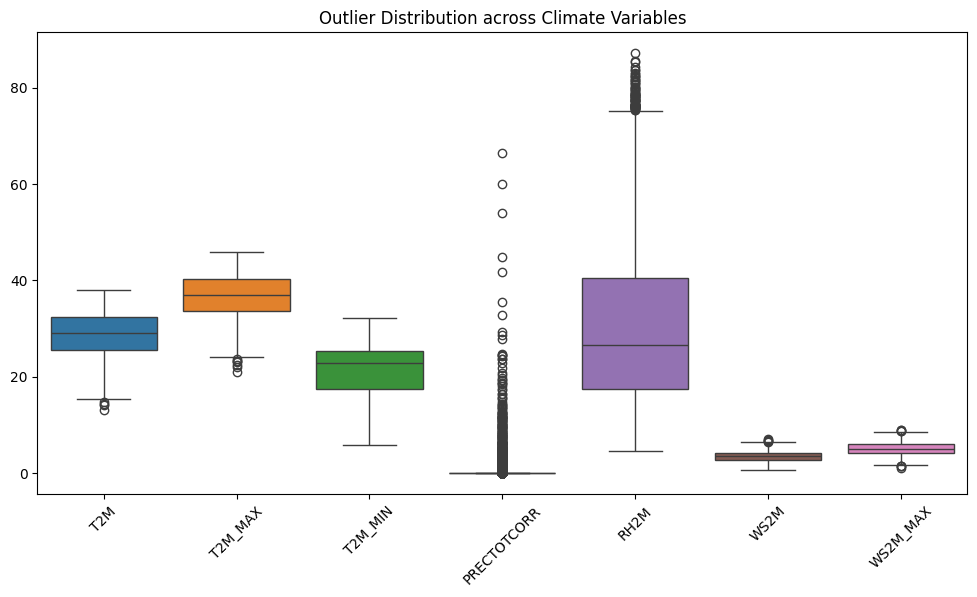

In [75]:
# Visualize outliers using a Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[cols_to_check])
plt.title("Outlier Distribution across Climate Variables")
plt.xticks(rotation=45)
plt.show()

Identify and drop rows that are mostly empty

In [76]:
missing_threshold = 0.3
mask_extreme_missing = df.isnull().mean(axis=1) > missing_threshold
df_cleaned = df[~mask_extreme_missing].copy()

In [77]:
# 2. Apply Forward Fill (ffill) to handle the remaining small gaps
# This propagates the last valid observation to the next valid one
df_cleaned.ffill(inplace=True)

,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,
2015-01-01,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,sudan,1
2015-01-02,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,sudan,1
2015-01-03,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,sudan,1
2015-01-04,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,sudan,1
2015-01-05,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,sudan,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,sudan,3
2026-03-28,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,sudan,3
2026-03-29,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,sudan,3


In [78]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print(f"Total nulls remaining: {df_cleaned.isna().sum().sum()}")

Original shape: (4108, 12)
Cleaned shape: (4108, 12)
Total nulls remaining: 0


In [79]:
output_path = "../data/sudan_clean.csv"
df_cleaned.to_csv(output_path)

print(f"Success! Cleaned data exported to: {output_path}")

Success! Cleaned data exported to: ../data/sudan_clean.csv


#### Time Series Analysis

Monthly Temperature Line Chart

In [80]:
# 1. Resample daily data to Monthly Mean (MS = Month Start)
monthly_temp = df_cleaned['T2M'].resample('MS').mean()

In [81]:
# 2. Identify the absolute records for annotation
warmest_val = monthly_temp.max()
warmest_date = monthly_temp.idxmax()

coolest_val = monthly_temp.min()
coolest_date = monthly_temp.idxmin()

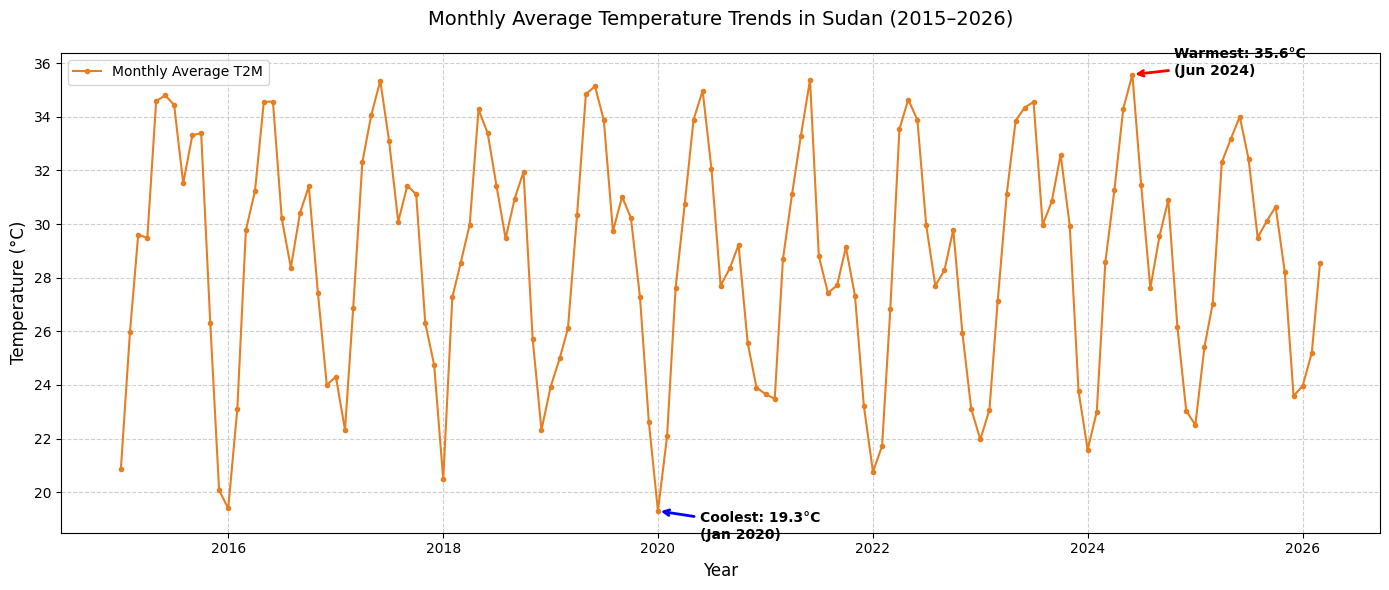

In [82]:
# 3. Create the Visualization
plt.figure(figsize=(14, 6))
plt.plot(monthly_temp, color='#e67e22', marker='o', markersize=3, linestyle='-', linewidth=1.5, label='Monthly Average T2M')

# 4. Add Annotations for the extremes
plt.annotate(f'Warmest: {warmest_val:.1f}°C\n({warmest_date.strftime("%b %Y")})', 
             xy=(warmest_date, warmest_val), 
             xytext=(30, 0), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold')

plt.annotate(f'Coolest: {coolest_val:.1f}°C\n({coolest_date.strftime("%b %Y")})', 
             xy=(coolest_date, coolest_val), 
             xytext=(30, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=2),
             fontsize=10, fontweight='bold')

# 5. Styling
plt.title('Monthly Average Temperature Trends in Sudan (2015–2026)', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

boxplot to see the distribution of temperature by month

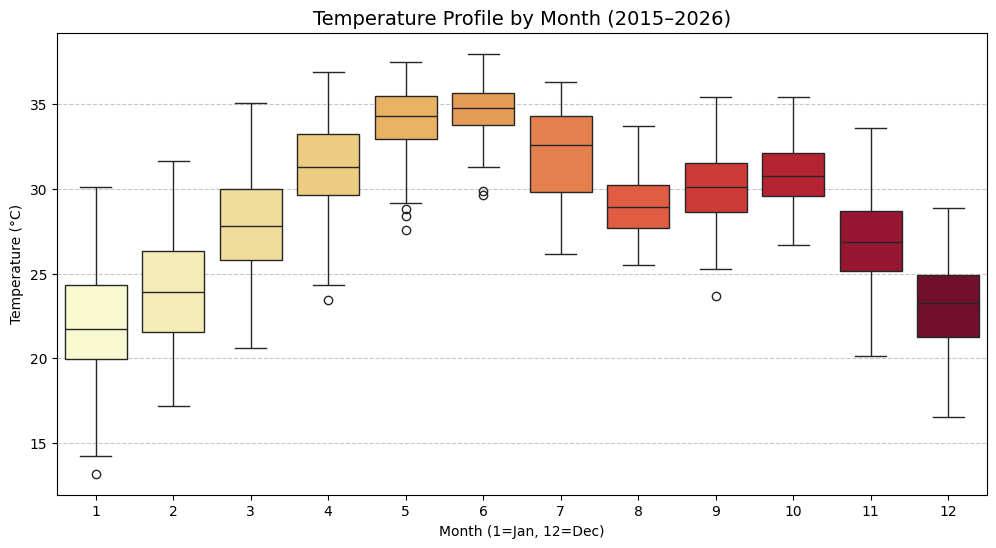

In [83]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='T2M', data=df_cleaned, 
            palette="YlOrRd", hue='Month', legend=False)

# Formatting
plt.title('Temperature Profile by Month (2015–2026)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Monthly Total Precipitation

In [84]:
# 1. Resample daily data to Monthly Total (Sum)
monthly_rain = df_cleaned['PRECTOTCORR'].resample('MS').sum()

In [85]:
# 2. Identify the peak rainy months (e.g., top 3 highest totals)
top_peaks = monthly_rain.nlargest(3)

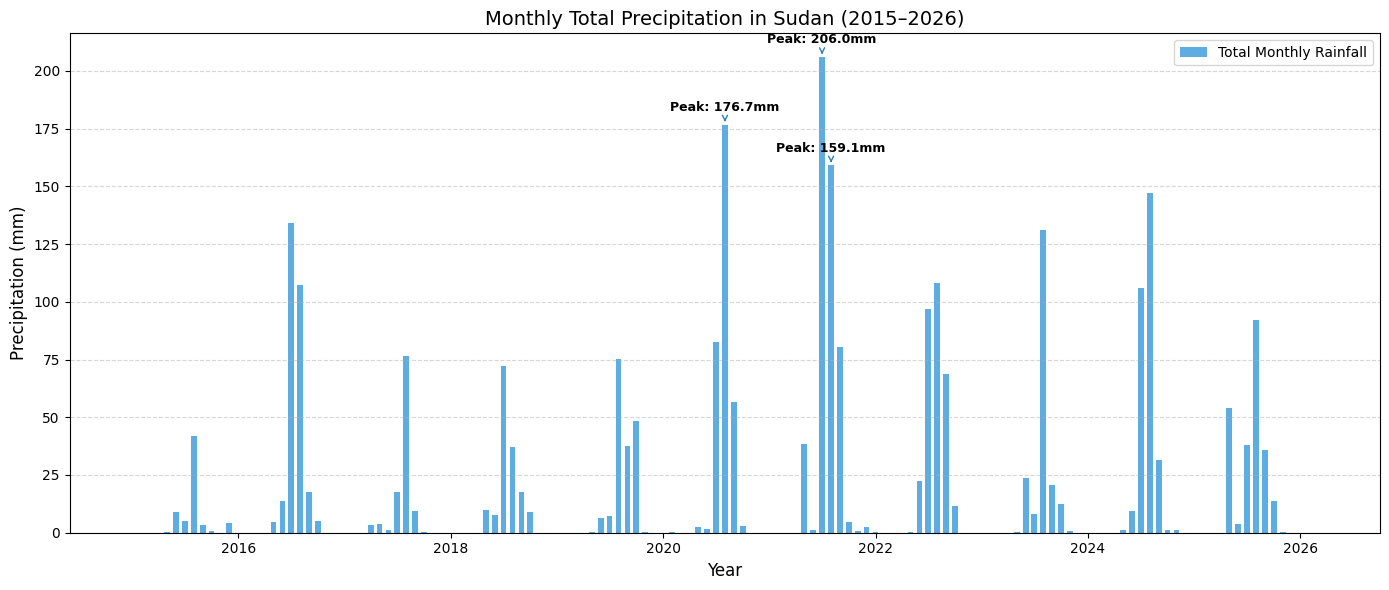

In [86]:
# 3. Create the Visualization
plt.figure(figsize=(14, 6))
plt.bar(monthly_rain.index, monthly_rain, color='#3498db', width=20, alpha=0.8, label='Total Monthly Rainfall')

# 4. Annotate the peaks
for date, val in top_peaks.items():
    plt.annotate(f'Peak: {val:.1f}mm', 
                 xy=(date, val), 
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#2980b9'))

# 5. Styling
plt.title('Monthly Total Precipitation in Sudan (2015–2026)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

boxplot to see the distribution of daily rainfall by month

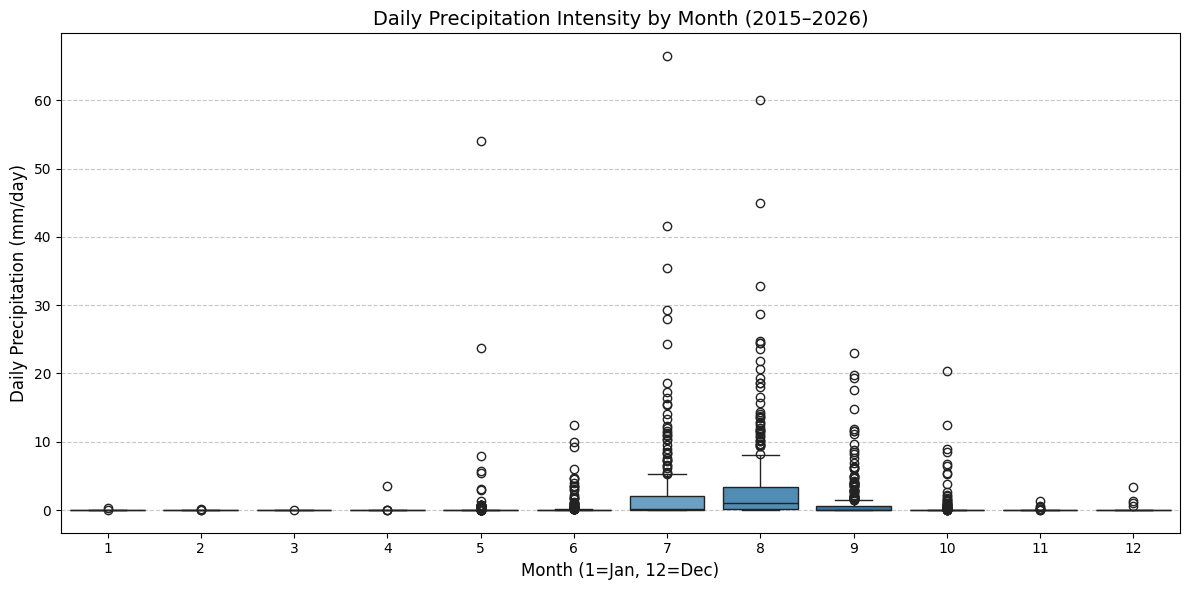

In [87]:
# Create a boxplot to see the distribution of daily rainfall by month
plt.figure(figsize=(12, 6))

# We use a Blue palette to represent water/rainfall
sns.boxplot(x='Month', y='PRECTOTCORR', data=df_cleaned, 
            palette="Blues", hue='Month', legend=False)

# Formatting
plt.title('Daily Precipitation Intensity by Month (2015–2026)', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Daily Precipitation (mm/day)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Yearly Average Temperature & Trend Line

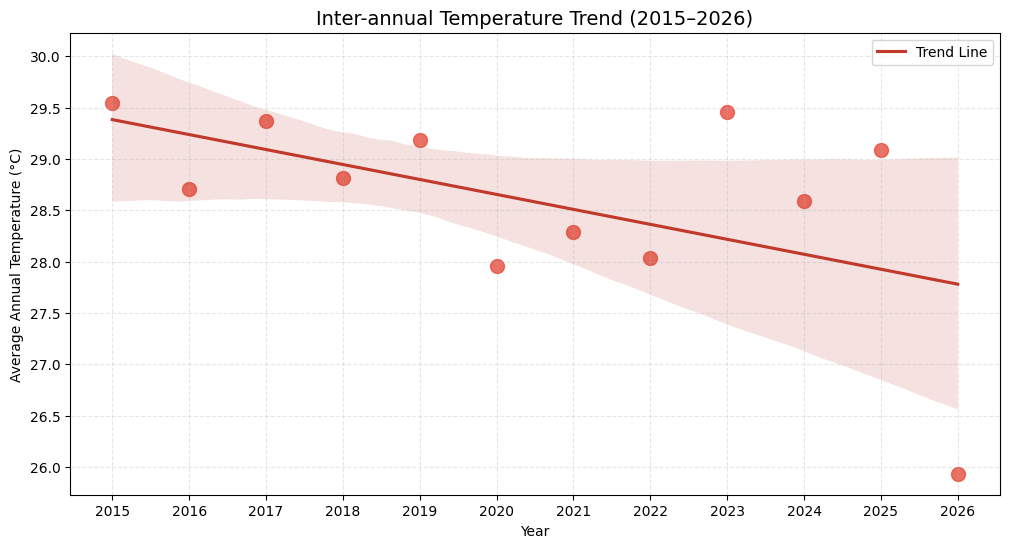

Success! Warming Rate: -0.1457 °C per year


In [88]:
# 1. Resample to get yearly averages
yearly_temp = df_cleaned['T2M'].resample('YE').mean().reset_index()

yearly_temp.columns = ['date', 'T2M']

# 3. Extract Year using the .dt accessor
yearly_temp['Year'] = yearly_temp['date'].dt.year

plt.figure(figsize=(12, 6))

# 4. Plot the Yearly Means and a Regression Line
sns.regplot(data=yearly_temp, x='Year', y='T2M', 
            scatter_kws={'s': 100, 'color': '#e74c3c'}, 
            line_kws={'color': '#c0392b', 'label': 'Trend Line'})

# 5. Labeling and Aesthetics
plt.title('Inter-annual Temperature Trend (2015–2026)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Annual Temperature (°C)')
plt.xticks(yearly_temp['Year']) 
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()

plt.show()

# 6. Calculate the Slope (Warming Rate)
slope, intercept, r_value, p_value, std_err = linregress(yearly_temp['Year'], yearly_temp['T2M'])
print(f"Success! Warming Rate: {slope:.4f} °C per year")

#### Correlation & Relationship Analysis

Correlation Heatmap

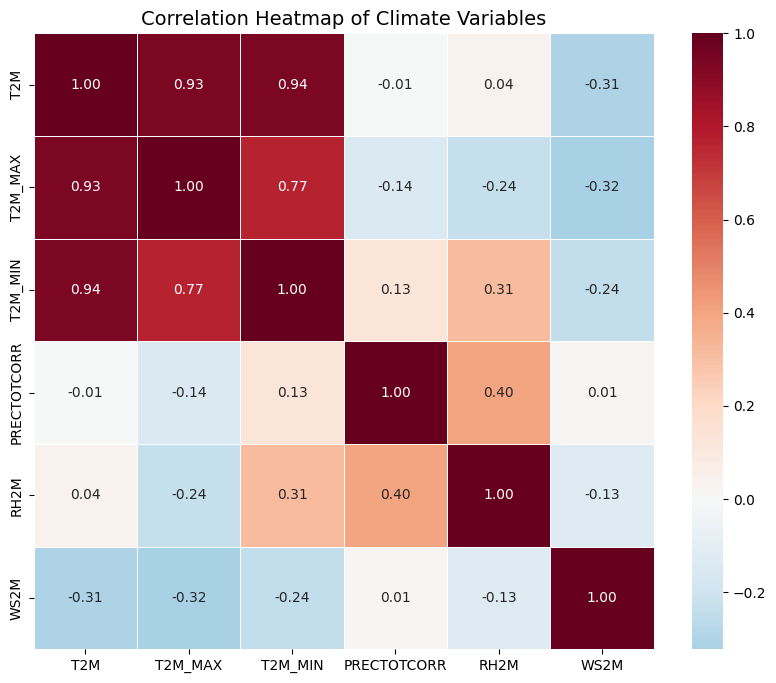

In [89]:
# 1. Calculate the correlation matrix
# We only include numeric columns that represent climate variables
corr_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M"]
corr_matrix = df_cleaned[corr_cols].corr()

# 2. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Climate Variables', fontsize=14)
plt.show()

Scatter Plots

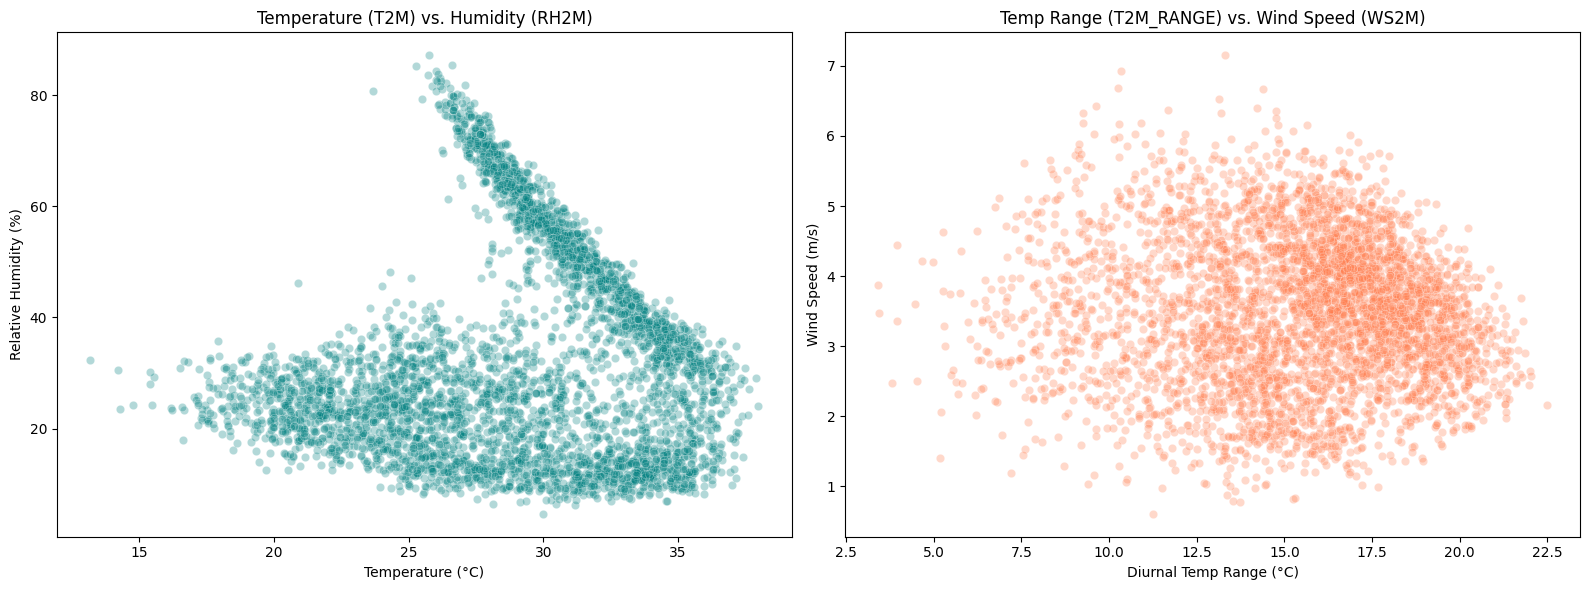

In [90]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs. Relative Humidity
sns.scatterplot(data=df_cleaned, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='teal')
ax1.set_title('Temperature (T2M) vs. Humidity (RH2M)')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs. Wind Speed
df_cleaned['T2M_RANGE'] = df_cleaned['T2M_MAX'] - df_cleaned['T2M_MIN']

sns.scatterplot(data=df_cleaned, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='coral')
ax2.set_title('Temp Range (T2M_RANGE) vs. Wind Speed (WS2M)')
ax2.set_xlabel('Diurnal Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

Pair Plot

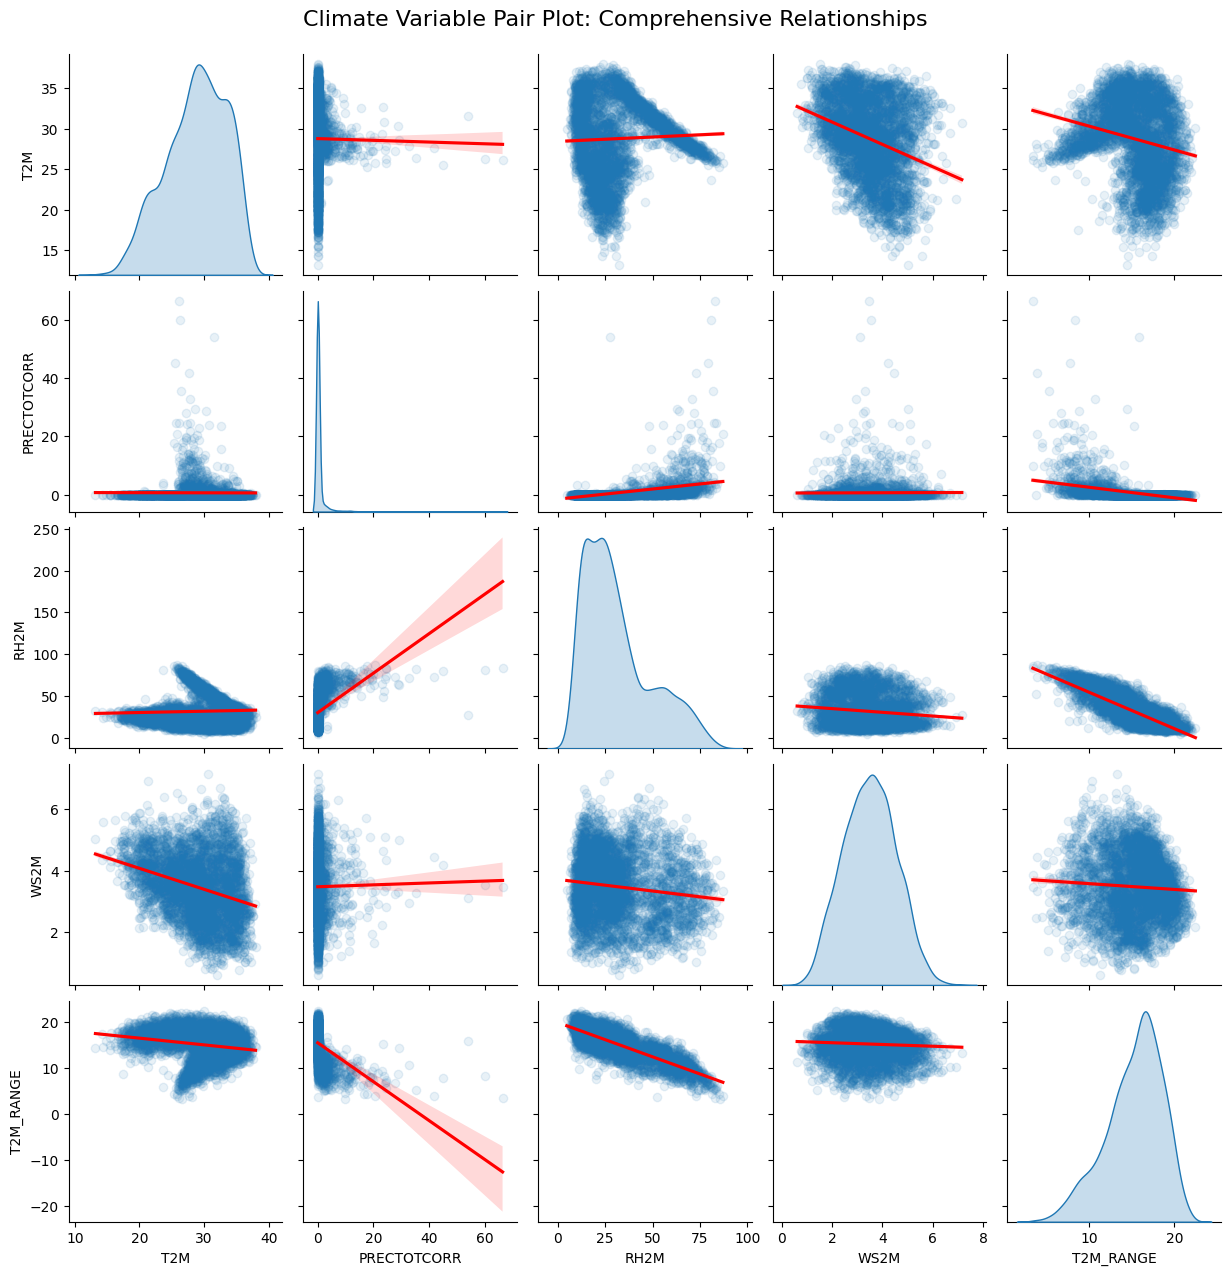

In [91]:
cols = ["T2M", "PRECTOTCORR", "RH2M", "WS2M", "T2M_RANGE"]


grid = sns.pairplot(df_cleaned[cols], 
                    kind='reg', 
                    diag_kind='kde', 
                    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})

grid.fig.suptitle('Climate Variable Pair Plot: Comprehensive Relationships', y=1.02, fontsize=16)
plt.show()

#### Distribution Analysis

In [92]:
skewness = df_cleaned['PRECTOTCORR'].skew()
print(f"Precipitation Skewness: {skewness:.2f}")

Precipitation Skewness: 10.29


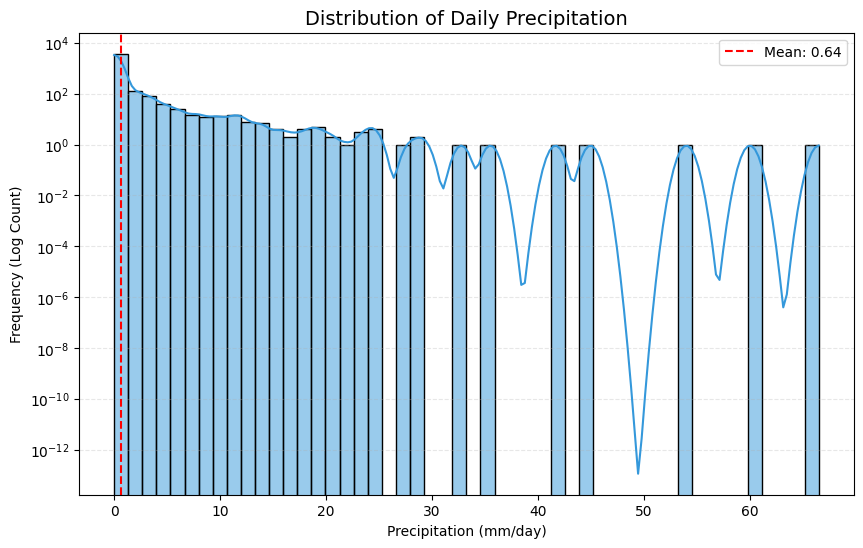

In [93]:
plt.figure(figsize=(10, 6))

# Plotting the histogram
# We keep bins at 50 to see the granularity of the storms
sns.histplot(df_cleaned['PRECTOTCORR'], bins=50, kde=True, color='#3498db')

# Applying the Log Scale because your skewness (3.17) is > 1
plt.yscale('log')

# Adding a vertical line for the mean to show how far the "tail" pulls it
plt.axvline(df_cleaned['PRECTOTCORR'].mean(), color='red', linestyle='--', label=f'Mean: {df_cleaned["PRECTOTCORR"].mean():.2f}')

plt.title('Distribution of Daily Precipitation', fontsize=14)
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Frequency (Log Count)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

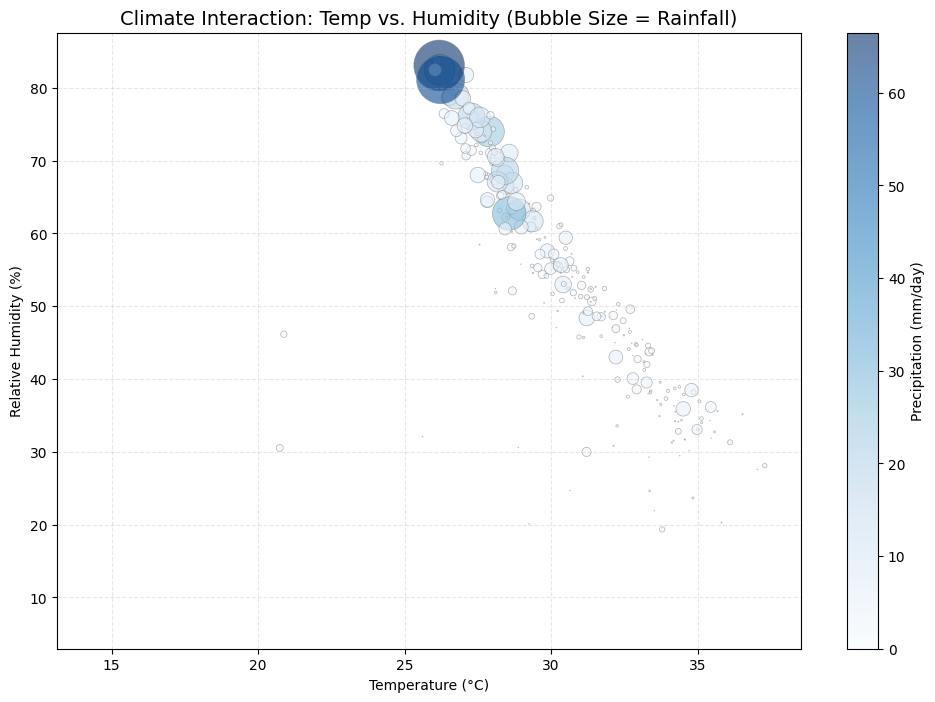

In [94]:
# 1. Take a sample to prevent bubbles from overlapping (1000 points is ideal)
df_sample = df_cleaned.sample(1000, random_state=42)

plt.figure(figsize=(12, 8))

# 2. Create the scatter plot
# s = size (scaled by rainfall), c = color (mapped to rainfall)
scatter = plt.scatter(df_sample['T2M'], 
                      df_sample['RH2M'], 
                      s=df_sample['PRECTOTCORR'] * 20, # Scale factor for visibility
                      c=df_sample['PRECTOTCORR'], 
                      cmap='Blues', 
                      alpha=0.6, 
                      edgecolors='grey', 
                      linewidth=0.5)

# 3. Add a colorbar for context
cbar = plt.colorbar(scatter)
cbar.set_label('Precipitation (mm/day)')

# 4. Final Styling
plt.title('Climate Interaction: Temp vs. Humidity (Bubble Size = Rainfall)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()